In [7]:
import numpy as np
from scipy import linalg
from sklearn.datasets import make_sparse_spd_matrix
from sklearn.covariance import GraphicalLassoCV, ledoit_wolf
import matplotlib.pyplot as plt
from concord import robust_selection, concord, datasets

In [10]:
# #############################################################################
# Generate the data
n_samples = 6000
n_features = 20

prng = np.random.RandomState(1)
prec = make_sparse_spd_matrix(n_features, alpha=.98,
                              smallest_coef=.4,
                              largest_coef=.7,
                              random_state=prng)
# _, prec = datasets.erodos_renyi_graph(n_features, edge_fraction=0.2)
cov = linalg.inv(prec)
d = np.sqrt(np.diag(cov))
cov /= d
cov /= d[:, np.newaxis]
prec *= d
prec *= d[:, np.newaxis]
X = prng.multivariate_normal(np.zeros(n_features), cov, size=n_samples)
X -= X.mean(axis=0)
X /= X.std(axis=0)

# #############################################################################
# Estimate the covariance
emp_cov = np.dot(X.T, X) / n_samples

model = GraphicalLassoCV()
model.fit(X)
cov_ = model.covariance_
prec_ = model.precision_

lw_cov_, _ = ledoit_wolf(X)
lw_prec_ = linalg.inv(lw_cov_)

optimal_lambda = robust_selection(X)
omega_concord = concord(X, optimal_lambda)
cov_concord = linalg.inv(omega_concord.todense())
print("optimal lambda: ", model.alpha_, optimal_lambda)          

optimal lambda:  0.02203219628136655 0.031018056335375067


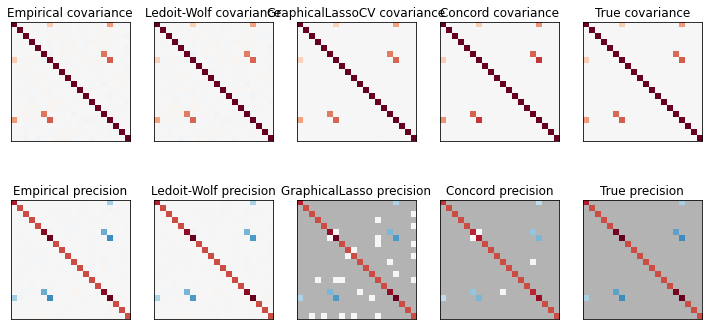

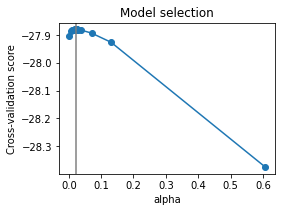

In [11]:
# #############################################################################
# Plot the results
plt.figure(figsize=(10, 6))
plt.subplots_adjust(left=0.02, right=0.98)

# plot the covariances
covs = [('Empirical', emp_cov), ('Ledoit-Wolf', lw_cov_),
        ('GraphicalLassoCV', cov_), ('Concord', cov_concord), ('True', cov)]
vmax = cov_.max()
for i, (name, this_cov) in enumerate(covs):
    plt.subplot(2, 5, i + 1)
    plt.imshow(this_cov, interpolation='nearest', vmin=-vmax, vmax=vmax,
               cmap=plt.cm.RdBu_r)
    plt.xticks(())
    plt.yticks(())
    plt.title('%s covariance' % name)


# plot the precisions
precs = [('Empirical', linalg.inv(emp_cov)), ('Ledoit-Wolf', lw_prec_),
         ('GraphicalLasso', prec_), ('Concord', omega_concord.todense()), ('True', prec)]
vmax = .9 * prec_.max()
for i, (name, this_prec) in enumerate(precs):
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(np.ma.masked_equal(this_prec, 0),
               interpolation='nearest', vmin=-vmax, vmax=vmax,
               cmap=plt.cm.RdBu_r)
    plt.xticks(())
    plt.yticks(())
    plt.title('%s precision' % name)
    if hasattr(ax, 'set_facecolor'):
        ax.set_facecolor('.7')
    else:
        ax.set_axis_bgcolor('.7')

# plot the model selection metric
plt.figure(figsize=(4, 3))
plt.axes([.2, .15, .75, .7])
plt.plot(model.cv_alphas_, np.mean(model.grid_scores_, axis=1), 'o-')
plt.axvline(model.alpha_, color='.5')
plt.title('Model selection')
plt.ylabel('Cross-validation score')
plt.xlabel('alpha')

plt.show()

In [12]:
a = np.array(np.arange(9)).reshape(3,3)
b = np.array([1.0, 2.0, 3.0])

In [14]:
print(a)
print(b)
a / b

[[0 1 2]
 [3 4 5]
 [6 7 8]]
[1. 2. 3.]


array([[0.        , 0.5       , 0.66666667],
       [3.        , 2.        , 1.66666667],
       [6.        , 3.5       , 2.66666667]])

In [17]:
a / np.sum(a, axis=1)

array([[0.        , 0.08333333, 0.0952381 ],
       [1.        , 0.33333333, 0.23809524],
       [2.        , 0.58333333, 0.38095238]])